Reading directional data...


c:\CIEM4230\Python\.venv\Lib\site-packages\windrose\windrose.py:670: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patch = mpl.patches.Rectangle(
c:\CIEM4230\Python\.venv\Lib\site-packages\windrose\windrose.py:670: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patch = mpl.patches.Rectangle(


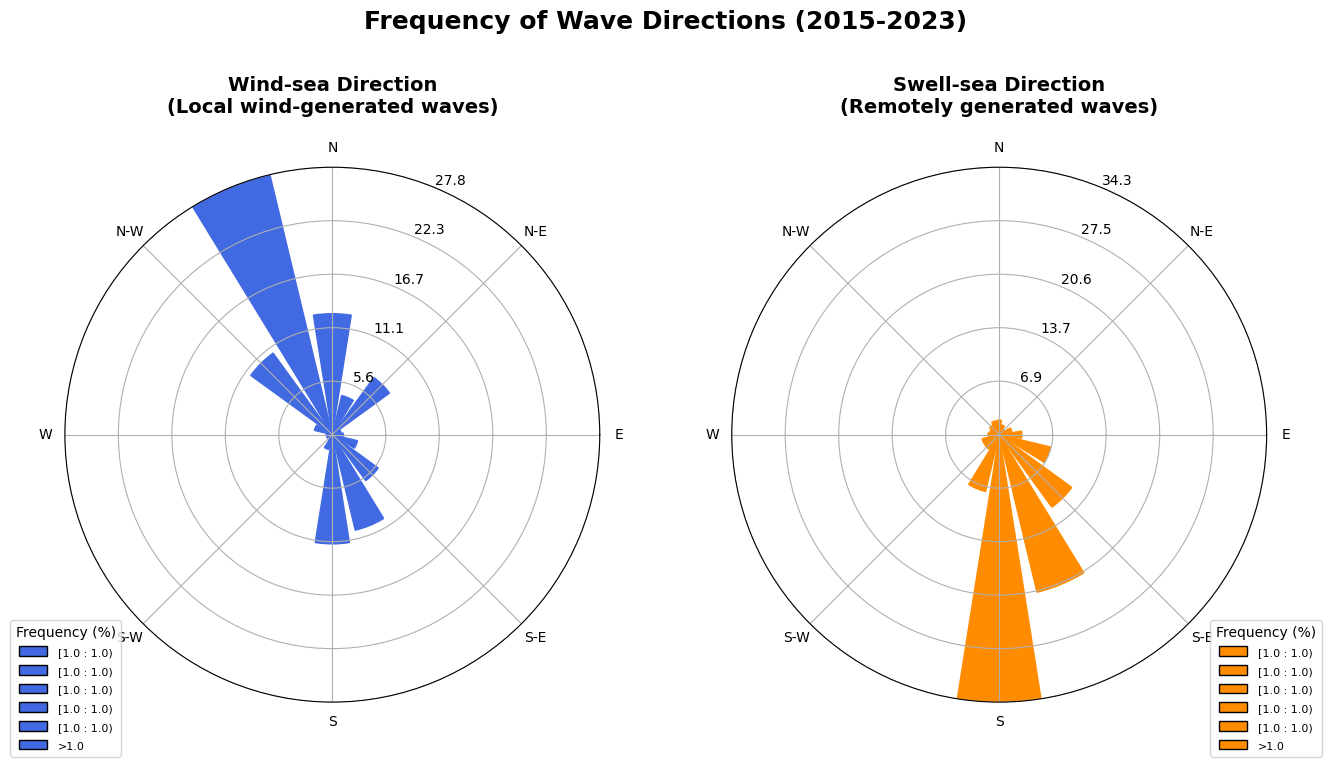

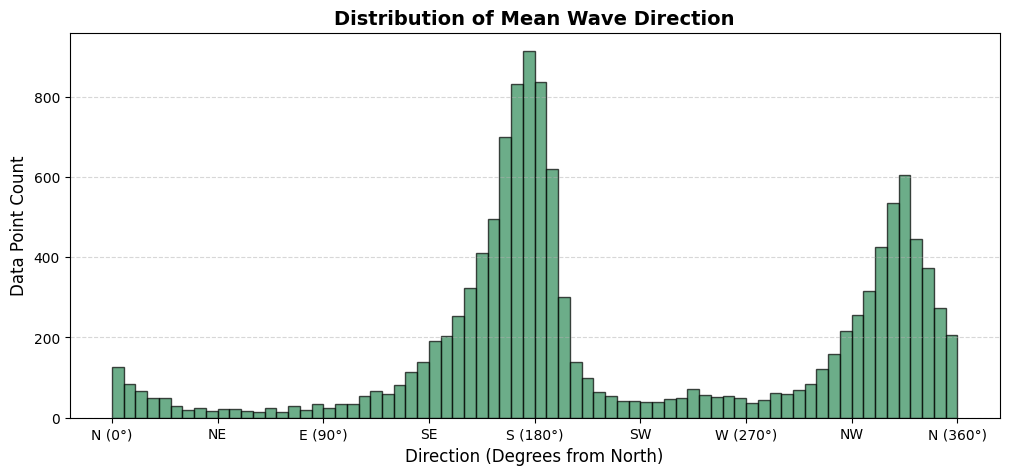

In [ ]:
from netCDF4 import Dataset
import numpy as np
import matplotlib.pyplot as plt
from windrose import WindroseAxes

# 1. Load and combine data
filenames = ['data/data_wave_direction_2015-19.nc', 'data/data_wave_direction_2020-23.nc']

all_mwd = []   # Mean Wave Direction (Total)
all_mdww = []  # Mean Direction of Wind Waves
all_mdts = []  # Mean Direction of Total Swell

for f in filenames:
    nc = Dataset(f, 'r')
    all_mwd.append(nc.variables['mwd'][:, 0, 0])
    all_mdww.append(nc.variables['mdww'][:, 0, 0])
    all_mdts.append(nc.variables['mdts'][:, 0, 0])
    nc.close()

# Concatenate to long arrays
mwd = np.concatenate(all_mwd)
mdww = np.concatenate(all_mdww)
mdts = np.concatenate(all_mdts)

# FIGURE 1: Directional Roses

# Creating two roses side-by-side to compare Wind-sea vs Swell
fig = plt.figure(figsize=(14, 7))

#  Wind-sea Rose 
ax1 = fig.add_subplot(121, projection="windrose")
ax1.bar(mdww, np.ones_like(mdww), nsector=16, normed=True, color='royalblue', edgecolor='white')
ax1.set_title("Wind-sea Direction\n(Local wind-generated waves)", fontsize=14, pad=20, fontweight='bold')
ax1.set_legend(title="Frequency (%)", loc='lower left', bbox_to_anchor=(-0.1, -0.1))

#  Swell Rose 

ax2 = fig.add_subplot(122, projection="windrose")
ax2.bar(mdts, np.ones_like(mdts), nsector=16, normed=True, color='darkorange', edgecolor='white')
ax2.set_title("Swell-sea Direction\n(Remotely generated waves)", fontsize=14, pad=20, fontweight='bold')
ax2.set_legend(title="Frequency (%)", loc='lower right', bbox_to_anchor=(1.1, -0.1))

plt.suptitle("Frequency of Wave Directions (2015-2023)", fontsize=18, y=1.05, fontweight='bold')
plt.tight_layout()
plt.show()

# FIGURE 2: Directional Distribution (Histogram)

plt.figure(figsize=(12, 5))
plt.hist(mwd, bins=72, range=(0, 360), color='seagreen', alpha=0.7, edgecolor='black')

plt.title("Distribution of Mean Wave Direction", fontsize=14, fontweight='bold')
plt.xlabel("Direction (Degrees from North)", fontsize=12)
plt.ylabel("Data Point Count", fontsize=12)

# Set ticks to compass directions
plt.xticks([0, 45, 90, 135, 180, 225, 270, 315, 360], 
           ['N (0°)', 'NE', 'E (90°)', 'SE', 'S (180°)', 'SW', 'W (270°)', 'NW', 'N (360°)'])

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()